In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
import re # Для работы с регулярными выражениями
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer # Для векторизации слов и определения их весов тексте
from sklearn.feature_extraction import text
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV # Для вероятностной оценки работы модели SVM


In [2]:
train_df = pd.read_json('train.json')
test_df = pd.read_json('test.json')

print(train_df.shape)
print(test_df.shape)

train_df.head()


(39774, 3)
(9944, 2)


,id,cuisine,ingredients
0,10259,greek,"[romaine lettuce, black olives, grape tomatoes..."
1,25693,southern_us,"[plain flour, ground pepper, salt, tomatoes, g..."
2,20130,filipino,"[eggs, pepper, salt, mayonaise, cooking oil, g..."
3,22213,indian,"[water, vegetable oil, wheat, salt]"
4,13162,indian,"[black pepper, shallots, cornflour, cayenne pe..."


In [3]:
test_df.head()

,id,ingredients
0,18009,"[baking powder, eggs, all-purpose flour, raisi..."
1,28583,"[sugar, egg yolks, corn starch, cream of tarta..."
2,41580,"[sausage links, fennel bulb, fronds, olive oil..."
3,29752,"[meat cuts, file powder, smoked sausage, okra,..."
4,35687,"[ground black pepper, salt, sausage casings, l..."


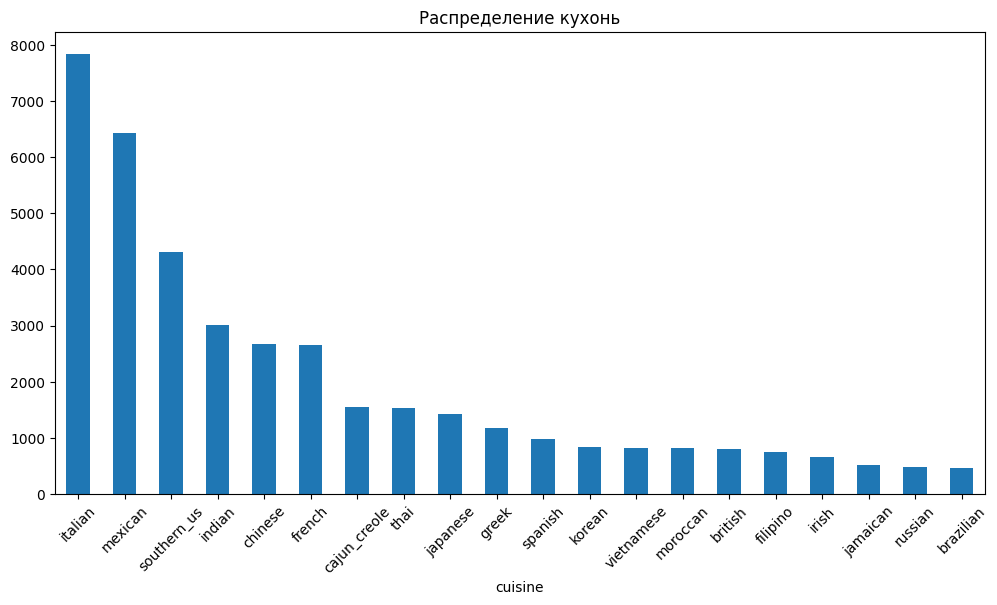

In [4]:
# Количественное соотношение классов (кухонь)
plt.figure(figsize=(12,6))
train_df['cuisine'].value_counts().plot(kind='bar')
plt.title('Распределение кухонь')
plt.xticks(rotation=45)
plt.show()


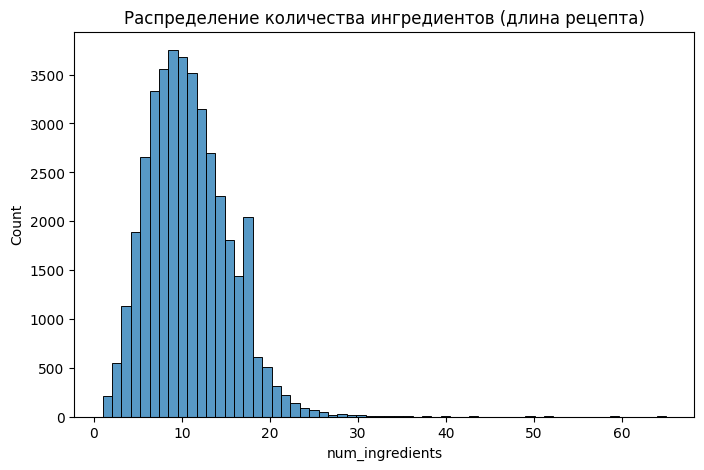

count    39774.000000
mean        10.767713
std          4.428978
min          1.000000
25%          8.000000
50%         10.000000
75%         13.000000
max         65.000000
Name: num_ingredients, dtype: float64


In [5]:
# Длина рецептов
train_df['num_ingredients'] = train_df['ingredients'].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(train_df['num_ingredients'], bins=60)
plt.title('Распределение количества ингредиентов (длина рецепта)')
plt.show()

print(train_df['num_ingredients'].describe())


Максимальное значение в пять раз превышает 75%, следовательно, некоторые данные (например, 1% самых длинных) можно исключить как экстремальные выбросы.

In [6]:
threshold = train_df['num_ingredients'].quantile(0.99)

train_df = train_df[train_df['num_ingredients'] <= threshold]


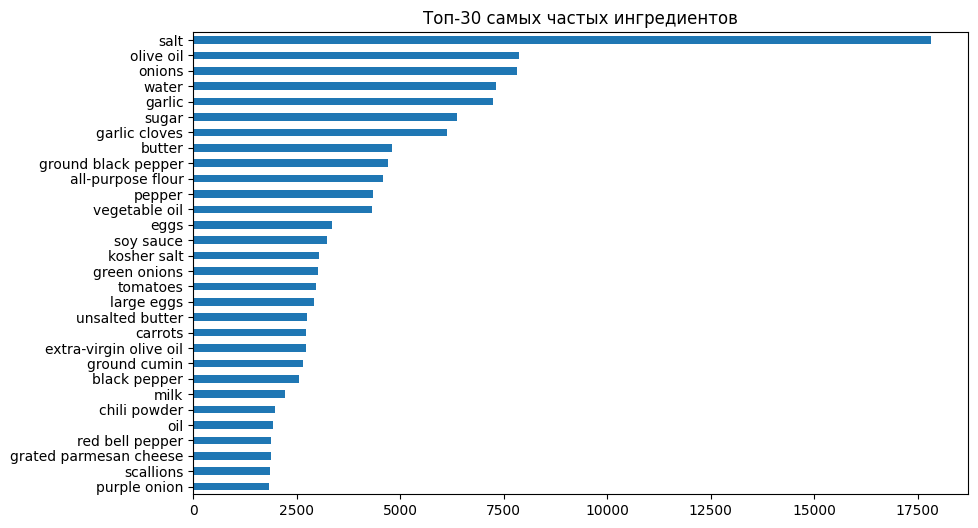

Всего уникальных ингредиентов: 6675


In [7]:
# Самые частые ингредиенты
all_ingredients = [item for sublist in train_df['ingredients'] for item in sublist]

ingredient_counts = pd.Series(all_ingredients).value_counts()

plt.figure(figsize=(10,6))
ingredient_counts.head(30).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Топ-30 самых частых ингредиентов')
plt.show()

print(f'Всего уникальных ингредиентов: {len(set(all_ingredients))}')


Присутствует дисбаланс классов: итальянской кухни намного больше, чем бразильской (модель будет стремиться предсказывать «итальянскую кухню» чаще)

Много (6479) уникальных компонентов. Скорее всего, там много дублей и близких по сути ингредиентов (pepper, ground pepper, black pepper...) а также редких ингредиентов, которые встречаются один раз.

Нужно привести ингредиенты к такому виду, чтобы модель не видела разницы между родственными понятиями - убираем символы, цифры, знаки препинания, пробелы и т.п. в компонентах и приводим данные к одному регистру. 

In [8]:
def clean_recipe(ingredients):
    text_recipe = ' '.join(ingredients).lower() # Соединяем список в строку и переводим в нижний регистр
    
    # Нормализация частых паттернов
    replacements = {
        'all-purpose': 'allpurpose',
        'all purpose': 'allpurpose',
        'low-fat': 'lowfat',
        'low fat': 'lowfat'
    }
    
    for k, v in replacements.items():
        text_recipe = text_recipe.replace(k, v)
    
    text_recipe = re.sub(r'[^a-z\s]', '', text_recipe) # Передаем задание: 'найди всё, что НЕ является буквами или пробелами (т.е. цифры, скобки, проценты, точки), и удали это'
    text_recipe = re.sub(r'\s+', ' ', text_recipe).strip() # Убираем лишние пробелы (если они возникли после удаления символов)
    
    return text_recipe

# Применяем метод к датасету и создаем новый признак - очищенные данные ингредиентов
train_df['clean_text'] = train_df['ingredients'].apply(clean_recipe)
test_df['clean_text'] = test_df['ingredients'].apply(clean_recipe)

test_df[['ingredients', 'clean_text']].head()


,ingredients,clean_text
0,"[baking powder, eggs, all-purpose flour, raisi...",baking powder eggs allpurpose flour raisins mi...
1,"[sugar, egg yolks, corn starch, cream of tarta...",sugar egg yolks corn starch cream of tartar ba...
2,"[sausage links, fennel bulb, fronds, olive oil...",sausage links fennel bulb fronds olive oil cub...
3,"[meat cuts, file powder, smoked sausage, okra,...",meat cuts file powder smoked sausage okra shri...
4,"[ground black pepper, salt, sausage casings, l...",ground black pepper salt sausage casings leeks...


In [9]:
#Смотрим самые популярные слова 
all_words = []
for recipe in train_df['clean_text']:
    all_words.extend(recipe.split())

word_counts = Counter(all_words)
word_counts.most_common(20)


[('pepper', 25138),
 ('salt', 24075),
 ('oil', 22967),
 ('garlic', 18551),
 ('ground', 17853),
 ('fresh', 17566),
 ('sauce', 12868),
 ('sugar', 12341),
 ('onions', 12104),
 ('cheese', 11660),
 ('chicken', 11214),
 ('olive', 10789),
 ('black', 10321),
 ('water', 9610),
 ('red', 8976),
 ('flour', 8734),
 ('butter', 8524),
 ('tomatoes', 8406),
 ('green', 8318),
 ('powder', 8008)]

In [10]:
#Смотрим самые популярные биграмы 
bigrams = []
for recipe in train_df['clean_text']:
    words = recipe.split()
    bigrams.extend(zip(words, words[1:]))

bigram_counts = Counter(bigrams)
bigram_counts.most_common(20)


[(('olive', 'oil'), 10785),
 (('black', 'pepper'), 7881),
 (('garlic', 'cloves'), 6981),
 (('ground', 'black'), 4922),
 (('soy', 'sauce'), 4755),
 (('vegetable', 'oil'), 4668),
 (('allpurpose', 'flour'), 4602),
 (('bell', 'pepper'), 4121),
 (('green', 'onions'), 3490),
 (('chicken', 'broth'), 3339),
 (('kosher', 'salt'), 3115),
 (('red', 'pepper'), 3102),
 (('lemon', 'juice'), 3048),
 (('large', 'eggs'), 2962),
 (('parmesan', 'cheese'), 2818),
 (('unsalted', 'butter'), 2750),
 (('extravirgin', 'olive'), 2720),
 (('ground', 'cumin'), 2670),
 (('chopped', 'cilantro'), 2450),
 (('brown', 'sugar'), 2429)]

In [11]:
my_stop_words = text.ENGLISH_STOP_WORDS.union(
    ['and', 
    'drain',
    'drained',
    'squeezed',
    'farmer',
    'organic',
    'ground']
)


In [12]:
# Векторизируем ингредиенты 
tfidf = TfidfVectorizer(
    ngram_range=(1,2), # ngram_range=(1, 2) позволит модели видеть и 'pepper', и 'black pepper' как отдельные признаки
    max_features=40000,
    stop_words=list(my_stop_words),
    min_df=5, # убираем очень редкий шум
    max_df=0.7, # убираем слова, встречающиеся в >70% рецептов
    )

X = tfidf.fit_transform(train_df['clean_text'])
y = train_df['cuisine']

# Векторизируем тестовые данные на будущее по той же схеме
X_test = tfidf.transform(test_df['clean_text'])

print(X.shape)


(39442, 17585)


In [13]:
# Разбиваем тренировочный файл на обучающую и валидационную выборки
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [14]:
#Обучаем модель - Наивный Байес
nb = MultinomialNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_val)

print('Naive Bayes')
print(classification_report(y_val, y_pred_nb))


Naive Bayes
              precision    recall  f1-score   support

   brazilian       1.00      0.10      0.18        92
     british       0.00      0.00      0.00       160
cajun_creole       0.88      0.48      0.62       305
     chinese       0.51      0.92      0.66       532
    filipino       0.86      0.04      0.08       151
      french       0.52      0.31      0.39       527
       greek       0.93      0.17      0.28       234
      indian       0.77      0.91      0.83       589
       irish       0.67      0.02      0.03       133
     italian       0.58      0.90      0.70      1564
    jamaican       1.00      0.02      0.04       103
    japanese       0.99      0.37      0.54       283
      korean       1.00      0.14      0.24       165
     mexican       0.78      0.92      0.84      1272
    moroccan       1.00      0.14      0.24       162
     russian       0.00      0.00      0.00        97
 southern_us       0.49      0.74      0.59       860
     spanish   

d:\Python 310.20\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Python 310.20\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Python 310.20\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [15]:
#Обучаем модель - Логистическая регрессия
lr = LogisticRegression(class_weight='balanced')
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_val)

print('Logistic Regression')
print(classification_report(y_val, y_pred_lr))


Logistic Regression
              precision    recall  f1-score   support

   brazilian       0.50      0.70      0.58        92
     british       0.41      0.61      0.49       160
cajun_creole       0.67      0.83      0.74       305
     chinese       0.82      0.80      0.80       532
    filipino       0.57      0.72      0.63       151
      french       0.56      0.66      0.60       527
       greek       0.68      0.79      0.73       234
      indian       0.88      0.89      0.89       589
       irish       0.44      0.65      0.52       133
     italian       0.90      0.74      0.81      1564
    jamaican       0.67      0.72      0.69       103
    japanese       0.82      0.64      0.72       283
      korean       0.73      0.81      0.77       165
     mexican       0.95      0.87      0.91      1272
    moroccan       0.73      0.83      0.78       162
     russian       0.40      0.63      0.49        97
 southern_us       0.78      0.67      0.72       860
     sp

In [16]:
#Обучаем модель - Метод опорных векторов
linsvm = LinearSVC(class_weight='balanced')
svm = CalibratedClassifierCV(linsvm, cv=3) # Добавляем калибратор для получения вероятностей
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_val)

print('Linear SVM')
print(classification_report(y_val, y_pred_svm))


Linear SVM
              precision    recall  f1-score   support

   brazilian       0.76      0.58      0.65        92
     british       0.62      0.41      0.50       160
cajun_creole       0.80      0.78      0.79       305
     chinese       0.77      0.86      0.82       532
    filipino       0.74      0.64      0.68       151
      french       0.60      0.65      0.62       527
       greek       0.81      0.71      0.76       234
      indian       0.84      0.91      0.87       589
       irish       0.64      0.49      0.56       133
     italian       0.80      0.89      0.84      1564
    jamaican       0.80      0.67      0.73       103
    japanese       0.83      0.64      0.72       283
      korean       0.82      0.78      0.80       165
     mexican       0.91      0.93      0.92      1272
    moroccan       0.85      0.74      0.79       162
     russian       0.64      0.40      0.49        97
 southern_us       0.73      0.79      0.76       860
     spanish    

Для SVM macro F1 ≈ 0.71 при accuracy 0.79 значит, что модель хорошо угадывает частые кухни, но редкие кухни хуже (видно, что русская и британская кухни предсказываютя хуже всего), закономерно при дисбалансе.
Наиболее слабо определяются русская и британская кухни.

In [17]:
results = {
    'Logistic Regression': accuracy_score(y_val, y_pred_lr),
    'Naive Bayes': accuracy_score(y_val, y_pred_nb),
    'Linear SVM': accuracy_score(y_val, y_pred_svm)
}

print(f'''Точность моделей:
{pd.Series(results).sort_values(ascending=False)}''')


Точность моделей:
Linear SVM             0.787933
Logistic Regression    0.756623
Naive Bayes            0.630245
dtype: float64


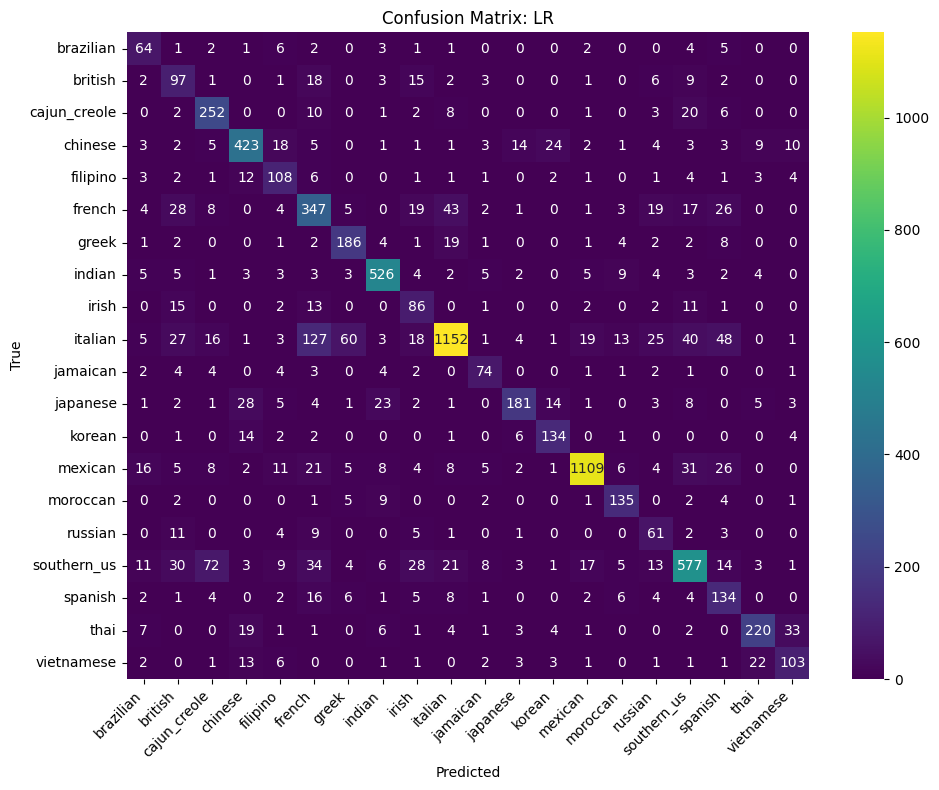

In [18]:
labels = sorted(y_val.unique())
cm = confusion_matrix(y_val, y_pred_lr, labels=labels)


plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix: LR')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


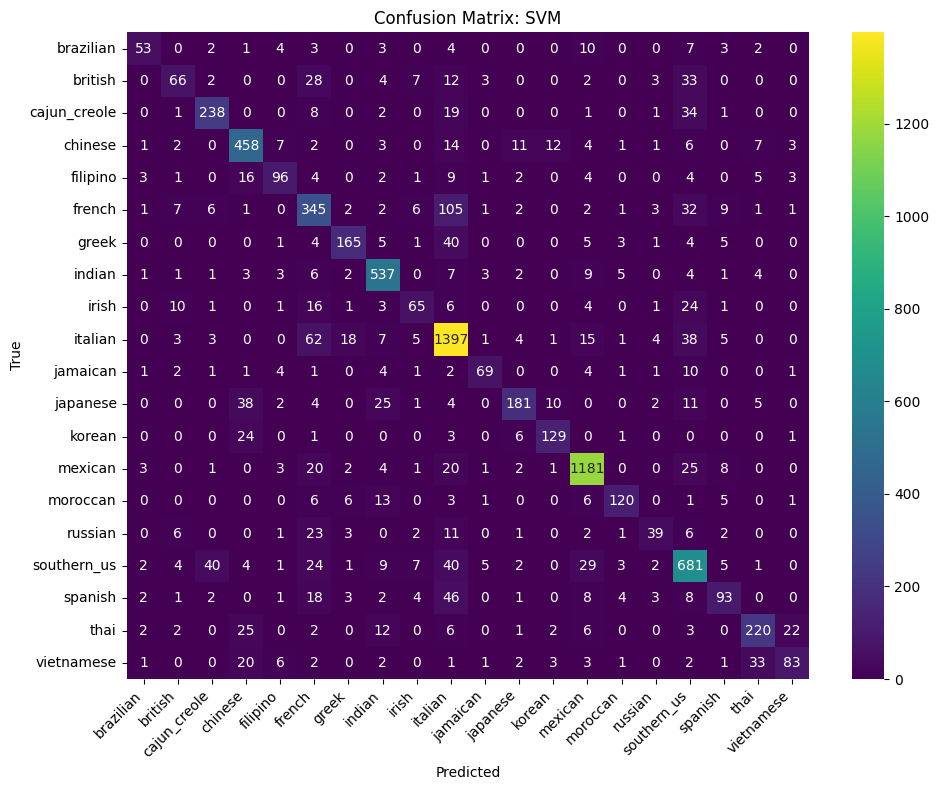

In [19]:
labels = sorted(y_val.unique())
cm = confusion_matrix(y_val, y_pred_svm, labels=labels)


plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix: SVM')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Обе модели чаще всего путают итальянскую и французскую кухни. 

В случае SVM предсказательная точность итальянской кухне выше. Так же видны паттерны, по которым близкородственные кухни чаще путаются (например, более редкий класс вьетнамской и тайской).

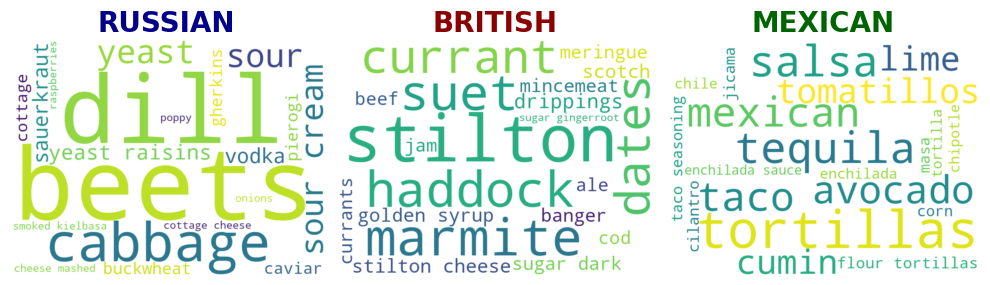

In [20]:
# Смотрим самые часто встречающиеся слова чтобы понимать, видит ли модель отличительные черты редких кухонь, а так же за счет каких слов лучше всего предсказывается мексиканская кухня

def generate_wordcloud(model_obj, cuisine, ax, title_color):
    idx = list(model_obj.classes_).index(cuisine) 
    if hasattr(model_obj, 'coef_'):
        coefs = model_obj.coef_[idx]
    else:
        coefs = np.mean([clf.estimator.coef_[idx] for clf in model_obj.calibrated_classifiers_], axis=0)
    feature_names = tfidf.get_feature_names_out()
    weights_dict = {feature_names[i]: coefs[i] for i in range(len(feature_names)) if coefs[i] > 0}
    
    wordcloud = WordCloud(
        width=800, 
        height=600, 
        background_color='white', 
        colormap = 'viridis',
        max_words=20
    ).generate_from_frequencies(weights_dict)
    
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(cuisine.upper(), fontsize=20, color=title_color, fontweight='bold')

fig, axes = plt.subplots(1, 3, figsize=(10, 5))

generate_wordcloud(svm, 'russian', axes[0],'darkblue')
generate_wordcloud(svm, 'british', axes[1],'darkred')
generate_wordcloud(svm, 'mexican', axes[2],'darkgreen')

plt.tight_layout()
plt.show()

In [21]:
# Делаем предсказание для тестовой выборки на основании лучшей модели - SVM. Выводим вероятность принадлежности к классу (общую и по кухням)
test_predictions = svm.predict(X_test) 

test_probs = svm.predict_proba(X_test) # Получаем матрицу вероятностей
cuisine_columns = svm.classes_

test_results = pd.DataFrame({
    'id': test_df['id'],
    'cuisine': test_predictions,
    'ingredients': test_df['ingredients']
})

probs_df = pd.DataFrame(test_probs, columns=svm.classes_)
probs_df = (probs_df * 100).round(2)
test_results = pd.concat([test_results, probs_df], axis=1)
test_results['conf_score'] = test_results[svm.classes_].max(axis=1)
cuisine_columns = list(svm.classes_)

cols_ordered = ['id', 'cuisine', 'conf_score'] + cuisine_columns + ['ingredients']
test_results = test_results[cols_ordered]

test_results.to_csv('test_results_svm.csv', index=False)

print('Готово! Файл test_results_svm.csv создан.')
print(f'Формат таблицы: {test_results.shape}')
print(test_results.head(10))


Готово! Файл test_results_svm.csv создан.
Формат таблицы: (9944, 24)
      id       cuisine  conf_score  brazilian  british  cajun_creole  chinese  \
0  18009       italian       28.50       0.30     2.68          0.16     1.26   
1  28583   southern_us       77.42       0.33     0.46          1.20     1.19   
2  41580       italian       79.72       0.25     1.38          1.73     1.20   
3  29752  cajun_creole       88.72       0.94     0.13         88.72     0.16   
4  35687       italian       86.70       0.43     0.21          0.21     0.09   
5  38527   southern_us       57.37       0.12    27.53          0.79     1.27   
6  19666       spanish       25.53       0.45     0.76          8.29     3.80   
7  41217       chinese       88.47       0.76     0.17          0.29    88.47   
8  28753       mexican       94.92       0.08     0.01          0.19     0.20   
9  22659       british       50.71       0.21    50.71          0.56     2.01   

   filipino  french  greek  ...  japane

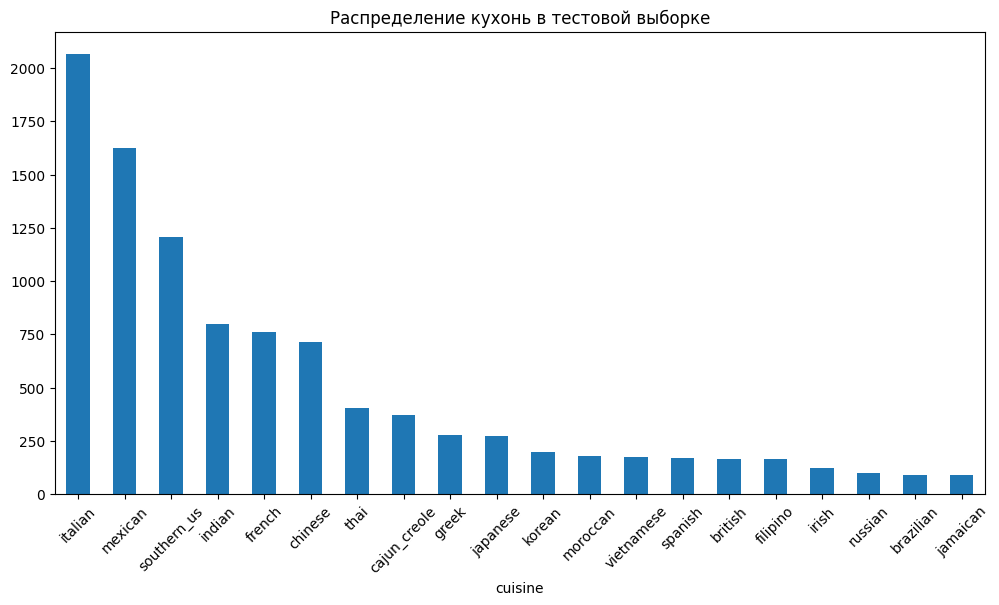

In [22]:
# Количественное соотношение классов (кухонь) в тестовой выборке
plt.figure(figsize=(12,6))
test_results['cuisine'].value_counts().plot(kind='bar')
plt.title('Распределение кухонь в тестовой выборке')
plt.xticks(rotation=45)
plt.show()


Соотношение кухонь в тестовой выборке похоже на то, что было в обучающей. Следовательно, модель SVM перенесла свои знания на практику. Вероятности распределения кухонь по классам приведены в файле test_results_svm.csv.
